In [ ]:
%matplotlib inline
# !pip install deeplay deeptrack  # Uncomment if running on Colab/Kaggle.


[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


<!--<badge>--><a href="https://colab.research.google.com/github/softmatterlab/DeepTrack-2.0/blob/develop/2-examples/DTEx213_multi_particle_tracking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a><!--</badge>-->

# Detecting Quantum Dots
This tutorial provides an example on how to set up a simulation pipeline using `DeepTrack2` to train a U-Net for quantum dots localizations in experimental images.

The dataset is acquired from a fluorescence microscope imaging quantum dots inside membrane proteins of living cells. 

## 1. Setup

Imports the objects needed for this example.

In [169]:
import os
import random
import zipfile

import deeplay as dl
import deeptrack as dt
import matplotlib.pyplot as plt
import numpy as np
import skimage as sk
import torch

## 2. Loading the Dataset


In [ ]:
def download_file_from_google_drive(
    file_id: str,
    root,
):
    try:
        import gdown
    except ModuleNotFoundError:
        raise RuntimeError(
            "To download files from GDrive, 'gdown' is required. You can install it with 'pip install gdown'."
        )
    root = os.path.expanduser(root)
    filename = file_id + ".zip"
    fpath = os.fspath(os.path.join(root, filename))
    os.makedirs(root, exist_ok=True)
    gdown.download(id=file_id, output=fpath, quiet=False)

    return fpath

In [ ]:
# Get the dataset id and folder name.
dataset_id = "1naaoxIaAU1F_rBaI-I1pB1K4Sp6pq_Jv"
folder_name = "QuantumDots"
model_id =  "131H6xdyC5gyTMQcnzb1ozztBH2nelWLg"
# Create the datasets folder if it doesn't exist.
if not os.path.exists("datasets"):
    os.mkdir("datasets")

dataset_path = f"datasets/{folder_name}"

# Skip if dataset already exists and has content.
if os.path.exists(dataset_path) and os.listdir(dataset_path):
    print("Dataset already downloaded.")
else:
    # Make dataset folder if missing.
    if not os.path.exists(dataset_path):
        os.mkdir(dataset_path)

    # Download zip file.
    print(f"Downloading {folder_name}...")
    fpath = download_file_from_google_drive(dataset_id, "datasets")

    # Extract zip file.
    print(f"Extracting {folder_name}...")
    with zipfile.ZipFile(fpath, "r") as zip_ref:
        zip_ref.extractall("datasets")

    # Delete zip file.
    os.remove(fpath)

    # Fix nested folder case.
    nested = f"{dataset_path}/{folder_name}"
    if os.path.isdir(nested) and not os.listdir(dataset_path):
        os.rename(nested, dataset_path)

### 2.1 Defining the training set

The training set consists of simulated 128 by 128 pixel images, containing multiple particles each. The particles are simulated as point scatterers. Their position in the camera plane is constrained to be within the image, and is sampled with a normal distribution with standard deviation of 5 pixel units in along the axis normal to the camera plane. 

In [ ]:
IMAGE_SIZE = 128
particle = dt.PointParticle(
    position=lambda: np.random.rand(2) * IMAGE_SIZE,
    z=lambda: np.random.randn() * 5,
    intensity=lambda: 1 + np.random.rand() * 9,
    position_unit="pixel",
)

number_of_particles = lambda: np.random.randint(10, 20)
particles = particle ^ number_of_particles

The particles are imaged using a fluorescence microscope with NA between 0.6 and 0.8, illuminating laser wavelength of 500 nm, and a magnification of 10.

In [6]:
optics = dt.Fluorescence(
    NA=lambda: 0.6 + np.random.rand() * 0.2,
    wavelength=500e-9,
    resolution=1e-6,
    magnification=10,
    output_region=(0, 0, IMAGE_SIZE, IMAGE_SIZE),
)

The noise is simulated as poisson noise with a signal to noise ratio between 4 and 7. The image is finally normalized by rescaling it to be contained between two random numbers within (0, 1).

In [ ]:
normalization = dt.NormalizeMinMax(
    min=lambda: np.random.rand() * 0.4,
    max=lambda min: min + 0.1 + np.random.rand() * 0.5,
)
noise = dt.Poisson(
    snr=lambda: 4 + np.random.rand() * 3,
    background=normalization.min
)

We now define how these objects combine

In [ ]:
imaged_particle = optics(particles)
simulated_particles = (
    dt.Value(imaged_particle)
    >> normalization
    >> noise
)

### 2.2 Defining the training labels

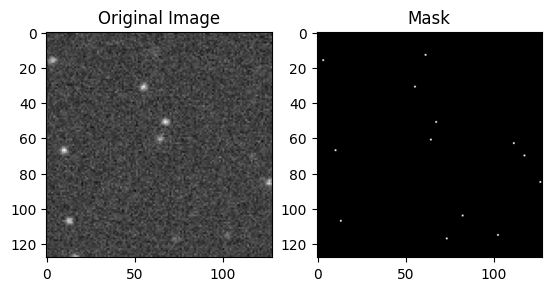

In [ ]:
get_masks = (particles
    >> dt.SampleToMasks(
        lambda: lambda particle: particle > 0,
        output_region=optics.output_region,
        merge_method="or"
    )
    >> dt.AsType("int")
    >> dt.OneHot(num_classes=2)
)

pipeline = (simulated_particles & get_masks) >> dt.MoveAxis(2, 0) >> dt.pytorch.ToTensor(dtype=torch.float)
pipeline.store_properties()

# Call pipeline to obtain simulated image with labels.
image, labels = pipeline.update()()
positions = np.array(image.get_property("position", get_one=False))

plt.subplot(1, 2, 1), plt.imshow(image[0, ...], cmap="gray")
plt.title("Original Image")
plt.subplot(1, 2, 2), plt.imshow(labels[1], cmap="gray")
plt.title("Mask")
plt.show()

### 2.3 Visualizing the Training Data

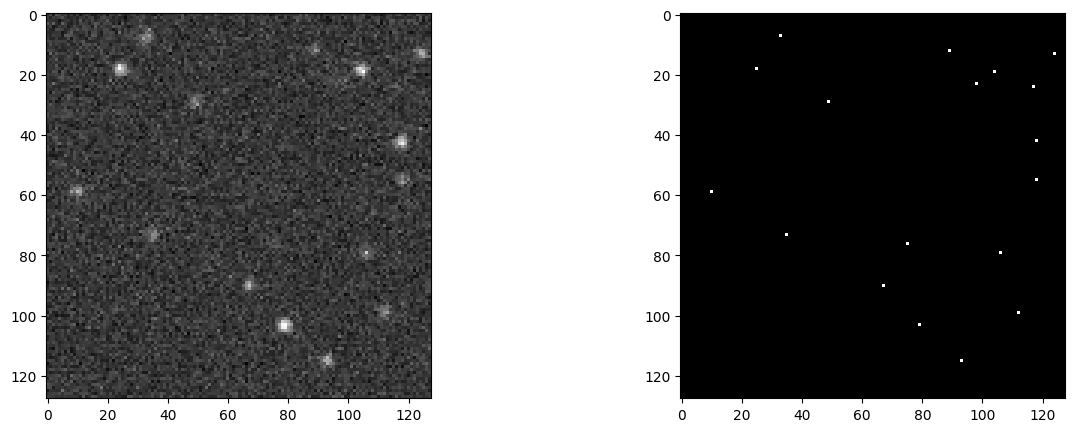

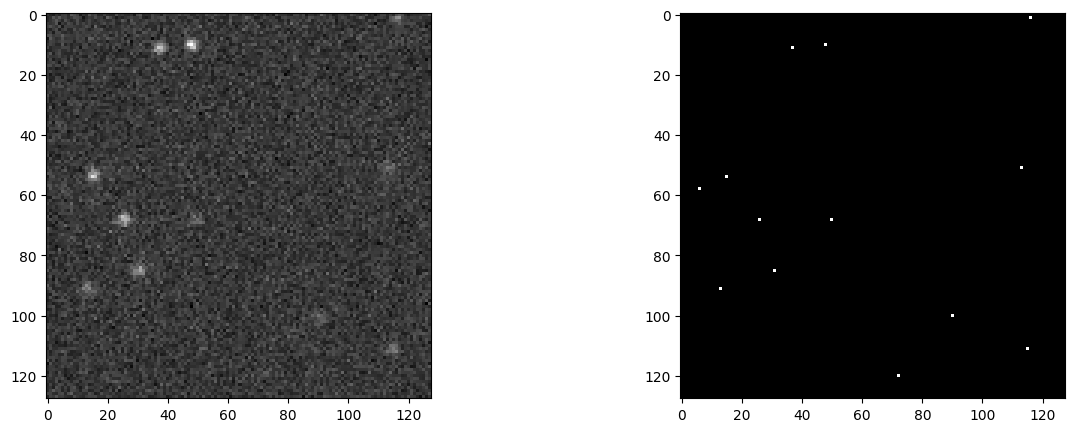

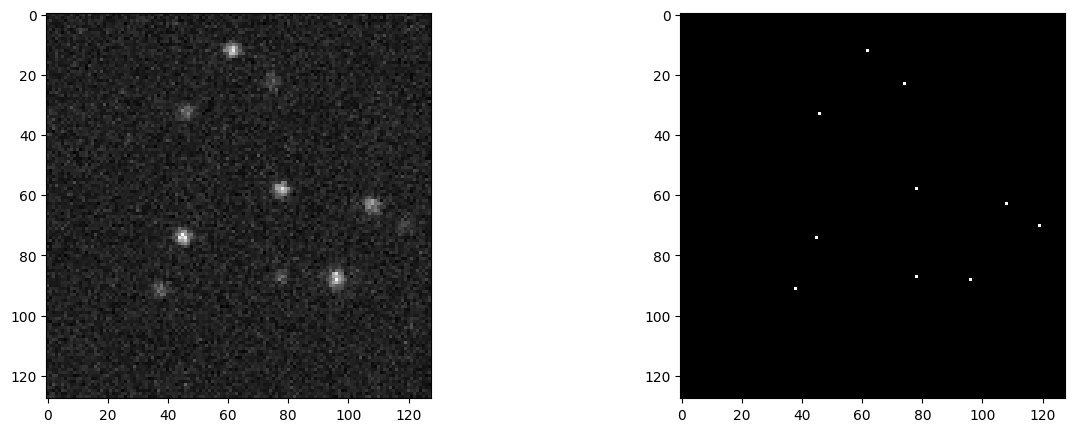

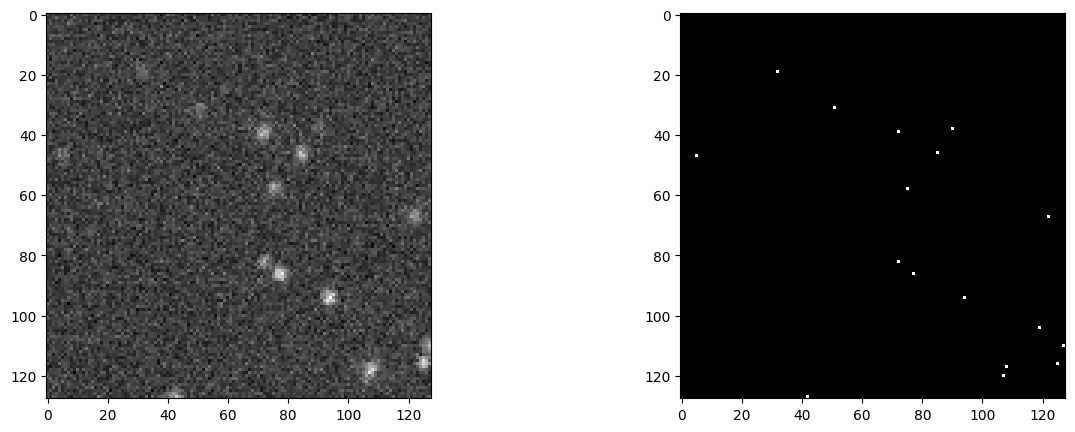

In [83]:
NUMBER_OF_IMAGES = 4

for _ in range(NUMBER_OF_IMAGES):
    plt.figure(figsize=(15, 5))
    simulated_particles.update()
    image_of_particle, labels = pipeline()
    plt.subplot(1, 2, 1)
    plt.imshow(image_of_particle[0, ...], cmap="gray")
    plt.subplot(1, 2, 2)
    plt.imshow(labels[1] * 1.0, cmap="gray")
    plt.show()

## 3. Defining the network

The network model used is a U-Net, implemented with `deeplay`.

In [189]:
model = dl.UNet2d(
    in_channels=None,
    encoder_channels=[32, 64],
    out_channels=2,
)
unet_regressor = dl.Regressor(
    model=model,
    loss = torch.nn.CrossEntropyLoss(weight=torch.tensor([1, 10])),
    optimizer=dl.Adam(lr=1e-3),
).build()

print(unet_regressor)

Regressor(
  (loss): CrossEntropyLoss()
  (optimizer): Adam[Adam](lr=0.001)
  (train_metrics): MetricCollection,
    prefix=train
  )
  (val_metrics): MetricCollection,
    prefix=val
  )
  (test_metrics): MetricCollection,
    prefix=test
  )
  (model): UNet2d(
    (encoder): ConvolutionalEncoder2d(
      (blocks): LayerList(
        (0): Conv2dBlock(
          (layer): LazyConv2d(0, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (activation): ReLU()
        )
        (1): Conv2dBlock(
          (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
          (layer): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (activation): ReLU()
        )
      )
      (postprocess): Identity()
    )
    (bottleneck): ConvolutionalNeuralNetwork(
      (blocks): LayerList(
        (0): Conv2dBlock(
          (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
          (layer): Conv2d(64, 64,

## 4. Training the network

INFO: 
  | Name          | Type             | Params | Mode 
-----------------------------------------------------------
0 | loss          | CrossEntropyLoss | 0      | train
1 | train_metrics | MetricCollection | 0      | train
2 | val_metrics   | MetricCollection | 0      | train
3 | test_metrics  | MetricCollection | 0      | train
4 | model         | UNet2d           | 114 K  | train
5 | optimizer     | Adam             | 0      | train
-----------------------------------------------------------
114 K     Trainable params
0         Non-trainable params
114 K     Total params
0.456     Total estimated model params size (MB)
34        Modules in train mode
0         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type             | Params | Mode 
-----------------------------------------------------------
0 | loss          | CrossEntropyLoss | 0      | train
1 | train_metrics | MetricCollection | 0      | train
2 | val_metrics   | MetricCollec

Training: |          | 0/? [00:00<?, ?it/s]

(<Figure size 1500x500 with 1 Axes>,
 array([[<Axes: title={'center': 'Loss'}, xlabel='Step'>]], dtype=object))

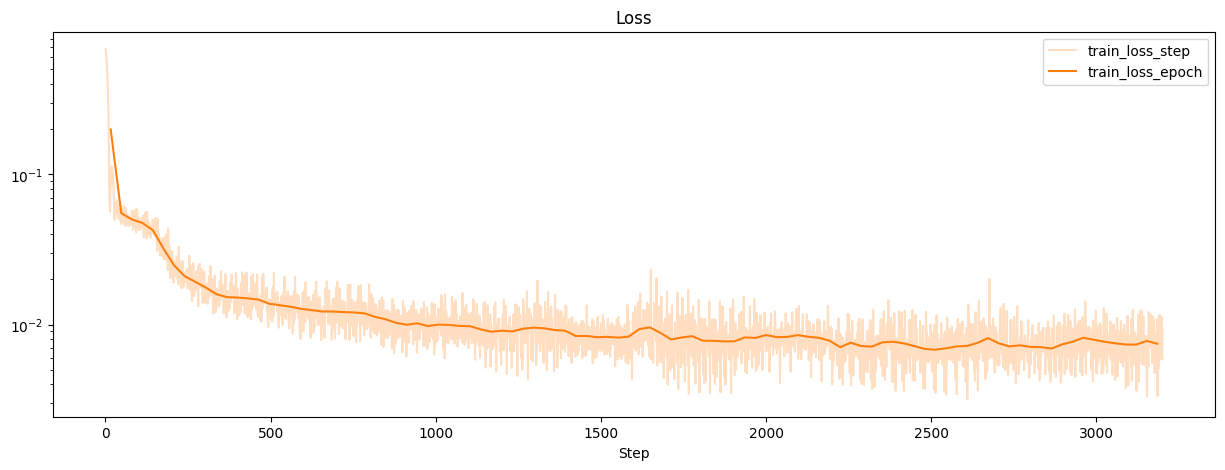

In [190]:
dataset = dt.pytorch.Dataset(
    pipeline,
    length=128,
    replace=.1
)
dataloader = dl.DataLoader(
    dataset,
    batch_size=4
)
unet_trainer = dl.Trainer(max_epochs=100, accelerator="auto")
unet_trainer.fit(unet_regressor, dataloader,)
unet_trainer.history.plot()

## 5. Evaluating the network

### 5.1 Prediction visualization

We show a few images, with the ground truth and network prediction.

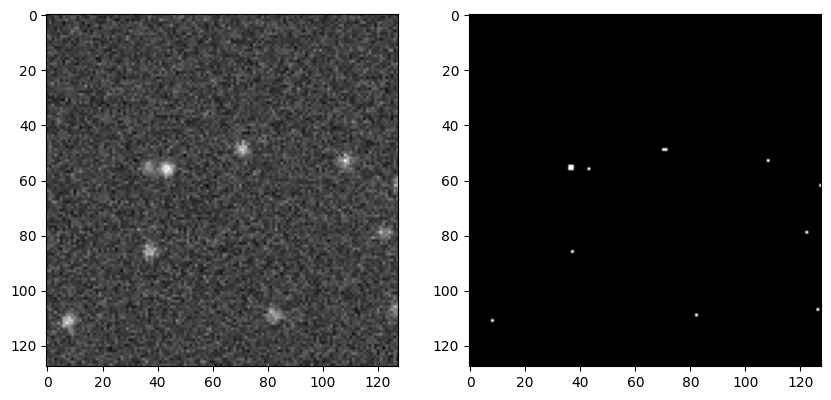

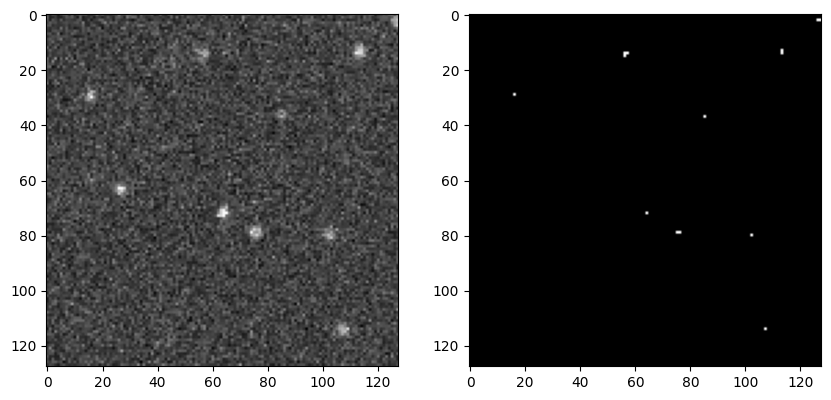

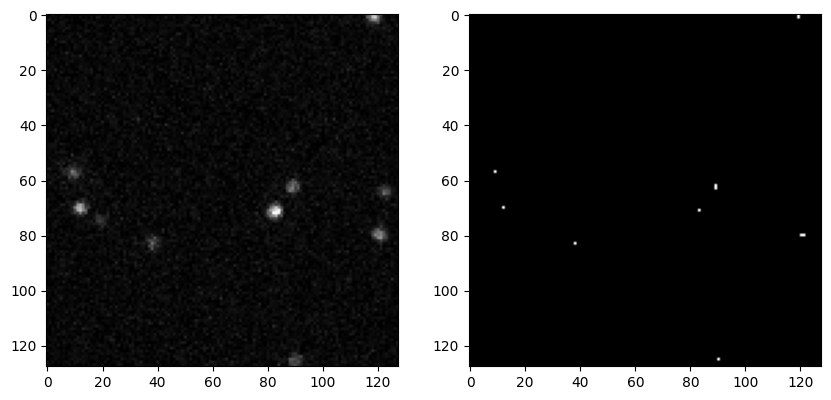

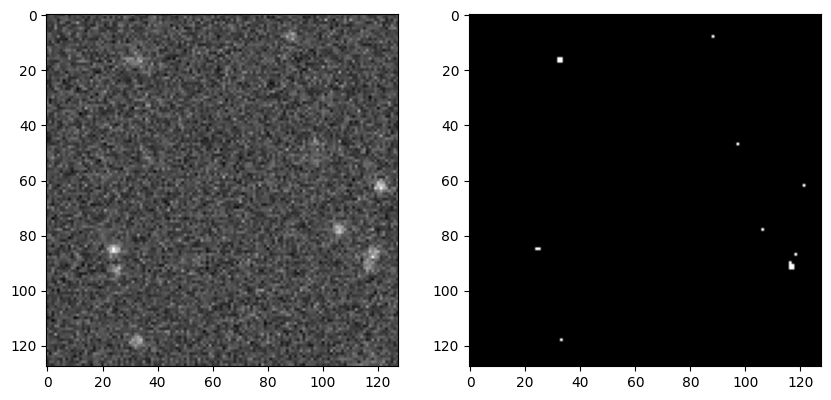

In [191]:
NUMBER_OF_IMAGES = 4


for _ in range(NUMBER_OF_IMAGES):
    plt.figure(figsize=(10, 10))
    pipeline.update()
    image_of_particles, labels = pipeline()
    
    predicted_mask = model(image_of_particles.unsqueeze(0))
    plt.subplot(1, 2, 1)
    plt.imshow(image_of_particles.squeeze(0), cmap="gray")
    plt.subplot(1, 2, 2)
    plt.imshow(predicted_mask[0, 1, ...] > 0.5, cmap="gray")
    plt.show()

### 5.2 Experimental Data
Sample random images from the quantum dots dataset, and overlay detections.

In [192]:
IMAGES_TO_PLAY = 64

# Load data.
images = sk.io.imread("./datasets/QuantumDots/Qdots.tif")
images = np.expand_dims(images[:IMAGES_TO_PLAY], axis=0)
images = dt.NormalizeMinMax(0, 1).resolve(list(images))

# Helper function to obtain detections.
def mask_to_positions(mask):
    """Convert binary mask to detections."""
    labels = sk.measure.label(mask)
    props = sk.measure.regionprops(labels)
    return np.array([prop.centroid for prop in props])

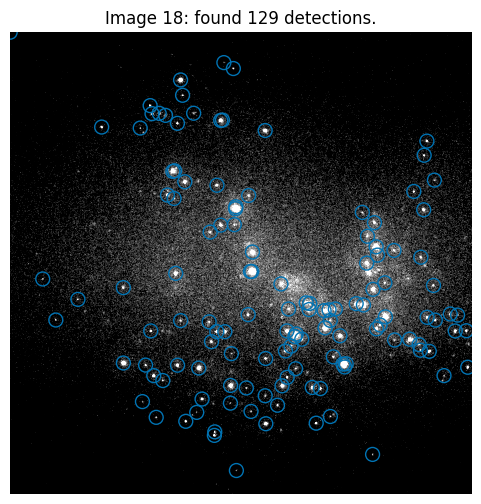

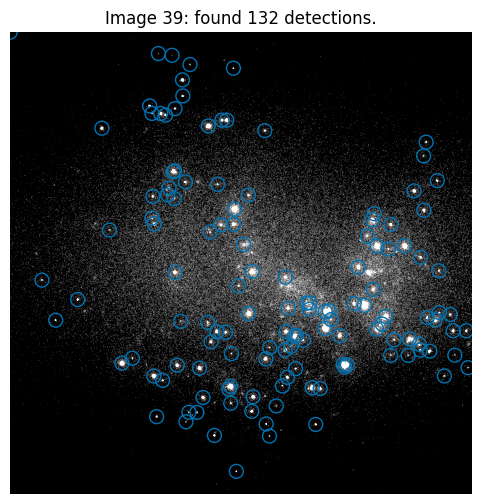

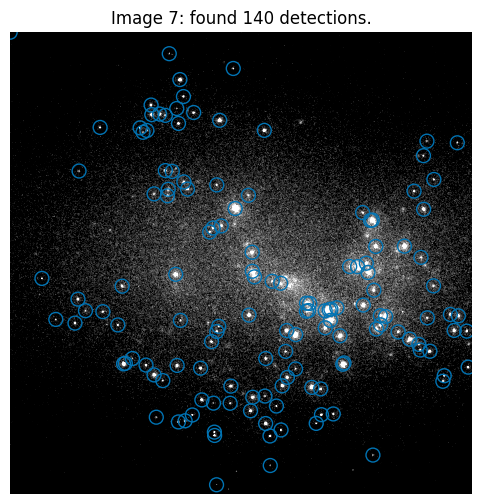

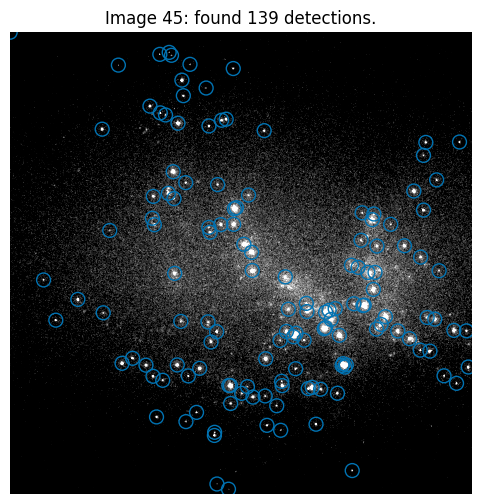

In [198]:
num_samples = 4
indices = random.sample(range(len(images)), num_samples)

for idx in indices:
    
    # Contrast scaling for plotting.
    vmin, vmax = np.percentile(images[idx], [50, 99])
    
    # Convert image to tensor
    image = torch.from_numpy(images[idx].astype(float)).unsqueeze(0).unsqueeze(0).to(torch.float32)
    
    prediction = model(image).detach()
    pred_mask = torch.nn.functional.softmax(prediction, dim=1)
    positions = mask_to_positions(pred_mask[0, 1, ...] > 0.001)

    plt.figure(figsize=(6, 6))
    plt.imshow(image[0, 0, ...], vmin=vmin, vmax=vmax, cmap="gray")
    
    if positions.shape[0] > 0:
        plt.scatter(
            positions[:, 1], positions[:, 0],
            s=100, facecolors="none",
            edgecolors=(0.0039, 0.45, 0.70)
        )
    
    plt.title(f"Image {idx}: found {len(positions[:, 1])} detections.")
    plt.axis("off")
    plt.show()